In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

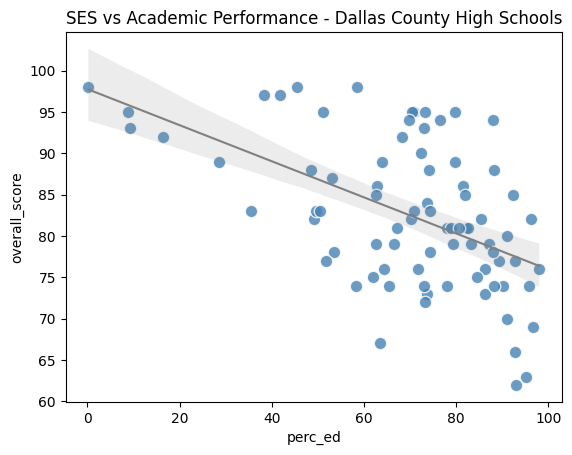

In [5]:
df = pd.read_csv("cleaned_dallas_data.csv")

df["overall_score"] = pd.to_numeric(df["overall_score"], errors="coerce")

df["perc_ed"] = (
    df["perc_ed"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

df["overall_score"] = df["overall_score"].replace({" ": None, ".": None})
df["overall_score"] = pd.to_numeric(df["overall_score"], errors="coerce")

df = df.dropna(subset=["perc_ed", "overall_score"])
fig, ax = plt.subplots()

sns.regplot(
    data=df,
    x="perc_ed",
    y="overall_score",
    ci=95,
    scatter_kws={"s": 80, "color": "steelblue", "edgecolors": "white"},
    line_kws={"color": "gray", "linewidth": 1.5},
    ax=ax
)

plt.title("SES vs Academic Performance - Dallas County High Schools")
plt.show()